In [4]:
import re, glob
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path

from nilearn.glm.first_level import make_first_level_design_matrix, FirstLevelModel
from nilearn.glm.contrasts import compute_fixed_effects
from nilearn.plotting import plot_stat_map, plot_design_matrix
from nilearn.glm import threshold_stats_img

In [5]:
# --- PATHS ---
#FMRIPREP_ROOT = Path("/volatile/home/sb283337/Bureau/7T-fMRI-Motor-Stroke/data/fmriprep")
FMRIPREP_ROOT = Path("/neurospin/motif-stroke/7T_protocol/pilots/derivatives/fmriprep")
HOME = Path.home()
BASE_DIR      = HOME / "7T-fMRI-Motor-Stroke"
EVENTS_DIR    = BASE_DIR / "data" / "events"
LOGS_DIR      = BASE_DIR / "data" / "log"
SEQ_DIR       = BASE_DIR / "data" / "seq"
RESULTS_DIR   = BASE_DIR / "results_joystick_V01"  # <-- Update this for new results

In [38]:
# --- SETTINGS ---
# Option A: "MNI152NLin2009cAsym" (For Group/Atlas)
# Option B: "T1w" (For Native/Clinical precision)
TASK = "joystick" # "motif4limbs" OR "joystick"
SPACE = "MNI152NLin2009cAsym"
TR = 1.6
BLANK_S = 1.0
PAUSE_S = 4.8
STIM_S  = 2.2 
SMOOTHING_FWHM = None
ALPHA_FDR = 0.05         # q < 0.001 for motif4limbs, 0.05 for joystick
ALPHA_BONF = 0.2          # alpha < 0.05 for motif4limbs, 0.1 for joystick
CLUSTER_THRESHOLD = 10     # Taille d'amas minimum
METHOD = "sequence"  # "sequence" OR "log" or behavioral
#BASE_RESULTS_DIR = Path("results_V01_joystick")

In [89]:
# --- CONTRASTS
CONTRASTS = {
    "task_gt_baseline": "0.25*(main_gauche + main_droite + pied_gauche + pied_droit)",
    "hand_vs_foot": "0.5*(main_gauche + main_droite) - 0.5*(pied_gauche + pied_droit)",
    "global_right_vs_left": "0.5*(main_droite + pied_droit) - 0.5*(main_gauche + pied_gauche)",
    "right_vs_left_hand": "main_droite - main_gauche",
    "right_vs_left_foot": "pied_droit - pied_gauche"

}


# --- ROI COORDINATES (MNI Space) ---
ROI_COORDS = {
    "SMA":            (0, -5, 65),     
    "M1_hand_L":      (-40, -25, 55),  
    "M1_hand_R":       (40, -25, 55),  
    "M1_foot_medial": (0, -30, 70),    
    "overview":       (0, -20, 60)
}

# --- ALIGNED VIEW MAPPING ---
CONTRAST_VIEWS = {
    "task_gt_baseline":     ["overview", "SMA"],
    "hand_vs_foot":         ["M1_hand_L", "M1_hand_R", "SMA"],
    "global_right_vs_left": ["overview", "SMA"],
    "right_vs_left_hand":   ["M1_hand_L", "M1_hand_R", "SMA"],
    "right_vs_left_foot":   ["M1_foot_medial", "SMA"]
}

In [7]:
CONTRASTS = {
    # 1. Total Movement (M1/SMA focus)
    # Includes the entire path from start to target
    "task_gt_baseline": "0.25*(left + left_reached + right + right_reached)",
    
    # 2. Spatial Direction (IPS focus)
    # This is the "GPS" contrast. 
    "right_vs_left":    "0.5*(right + right_reached) - 0.5*(left + left_reached)",
    "left_vs_right":    "0.5*(left + left_reached) - 0.5*(right + right_reached)",
    
    # 3. The "Success" Moment (Reward/Visual feedback)
    # This shows the brain's reaction to hitting the target
    "target_achieved":  "0.5*(left_reached + right_reached) - 0.5*(left + right)",

    "return_gt_move":   "center - 0.5*(left + right)"
}

# --- ROI COORDINATES (MNI Space - Optimized for Joystick)
# --- ROI COORDINATES (MNI Space) ---
ROI_COORDS = {
    "M1_hand_L":      (-38, -22, 56),  # Motor Engine (Right Hand)
    "SMA":            (0, -8, 62),     # Planning/Initiation
    "IPS_L":          (-26, -64, 48),  # Spatial GPS (Left)
    "IPS_R":          (26, -64, 48),   # Spatial GPS (Right)
    "Visual_V5":      (45, -75, 5),    # Visual Motion (Added to see cursor tracking)
    "overview":       (0, -20, 60)
}

# --- ALIGNED VIEW MAPPING

CONTRAST_VIEWS = {
    "task_gt_baseline": ["M1_hand_L", "SMA", "overview"],
    "right_vs_left":    ["IPS_L", "IPS_R","overview"], # Don't look at M1 here, it's empty!
    "left_vs_right":    ["IPS_L", "IPS_R","overview"], # Only IPS shows spatial shifts
    "return_gt_move":   ["SMA", "Visual_V5", "IPS_L"], # The 'Braking' network
    "target_achieved":  ["Visual_V5", "SMA", "overview"]
}

In [8]:

def get_motif_files(sub_id):
    """Strictly finds motif4limbs tasks and extracts run/dir."""
    func_dir = FMRIPREP_ROOT / f"sub-{sub_id}" / "func"
    # If SPACE is T1w, the filename has NO 'space-T1w' tag, it's just 'desc-preproc_bold'
    if SPACE == "T1w":
        pattern = f"sub-{sub_id}_task-{TASK}_dir-*_run-*_desc-preproc_bold.nii.gz"
    else:
        pattern = f"sub-{sub_id}_task-{TASK}_dir-*_run-*_space-{SPACE}_desc-preproc_bold.nii.gz"

    bolds = sorted(func_dir.glob(pattern))
    
    run_data = []
    for b in bolds:
        # Improved Regex to catch 'dir' and 'run'
        run_match = re.search(r"run-(\d+)", b.name)
        dir_match = re.search(r"dir-([a-z]+)", b.name)
        
        if run_match and dir_match:
            run_num = run_match.group(1)
            direc = dir_match.group(1)
            
            run_data.append({
                "run": run_num,
                "dir": direc,
                "bold": b,
                "mask": func_dir / b.name.replace("desc-preproc_bold.nii.gz", "desc-brain_mask.nii.gz"),
                "conf": func_dir / b.name.replace(f"space-{SPACE}_desc-preproc_bold.nii.gz", "desc-confounds_timeseries.tsv")
            })
    return run_data

In [9]:
def get_background_image(sub_id):
    """Finds the correct T1 for the background based on the chosen SPACE."""
    anat_dir = FMRIPREP_ROOT / f"sub-{sub_id}" / "anat"
    
    if SPACE == "T1w":
        # The Native T1
        bg = anat_dir / f"sub-{sub_id}_desc-preproc_T1w.nii.gz"
    else:
        # The T1 that was 'warped' to fit the MNI space
        bg = anat_dir / f"sub-{sub_id}_space-{SPACE}_desc-preproc_T1w.nii.gz"
        
    return str(bg) if bg.exists() else None

In [10]:
def build_events_sequence(run):
    """
    EXACT ORIGINAL LOGIC:
    - Onset depends on run ID (one file per run).
    - Uses specific BLANK_S and STIM_S increments to maintain timing.
    """
    seq_path = SEQ_DIR / f"stim_sequence_run-{int(run)}.csv"
    if not seq_path.exists():
        return None
    seq = pd.read_csv(seq_path).sort_values(["block_id", "id"])
    

    rows = []
    current = 0.0 # Starting t0
    current_block = None

    for _, r in seq.iterrows():
        # Block transition logic
        if current_block is None:
            current_block = r["block_id"]
        elif r["block_id"] != current_block:
            current += PAUSE_S
            current_block = r["block_id"]

        # Blank window (shifts the onset)
        current += BLANK_S

        # Record the stimulus window
        rows.append({
            "onset": current,
            "duration": STIM_S,
            "trial_type": r["block_name"],
            "modulation": 1.0
        })

        # Move to end of stimulus
        current += STIM_S

    return pd.DataFrame(rows) if rows else None


def build_events_tsv(tsv_path, log_path):
    """
    SYNC WORKER:
    Takes two specific file paths, aligns them to the TTL, 
    and returns a Nilearn-ready DataFrame.
    """
    # 1. The actual LOAD happens here
    df_tsv = pd.read_csv(tsv_path, sep='\t')
    
    # Use default sep=',' because raw log is a .csv
    df_log = pd.read_csv(log_path)
    
    # 2. Find the TTL anchor (The "Starting Gun")
    # We look for 'TTL' or the code '116'
    ttl_rows = df_log[df_log['event'].isin(['TTL', '116'])]
    t0 = ttl_rows.iloc[0]['time']
    
    # 3. Apply the synchronization math
    events = pd.DataFrame()
    
    # Reset onset to 0.0 based on the TTL and convert to seconds
    events['onset'] = (df_tsv['onset'] - t0) / 1000.0
    
    # Convert duration to seconds
    events['duration'] = df_tsv['duration'] / 1000.0
    
    # Keep the condition names
    events['trial_type'] = df_tsv['trial_type']
    
    # 4. Filter for Nilearn
    # We remove 'fix' or 'blank' because 'nothing' is the implicit baseline
    forbidden = ['fix', 'blank', 'fixation', 'rest', 'Start', 'End']
    events = events[~events['trial_type'].isin(forbidden)].copy()
    
    # Constant modulation for the GLM
    events['modulation'] = 1.0

    return events


def build_behavioral_file(log_csv_path):
    """
    Simplified version: Assumes TTL/116 always exists.
    Converts raw codes (49, 50, 98, 121) into task labels.
    """
    df = pd.read_csv(log_csv_path)
    df['event'] = df['event'].astype(str).apply(lambda x: x.split(':')[1] if 'key:' in x else x)

    
    # 1. Anchor to the FIRST pulse (TTL or 116)
    # We convert to string to catch both types of labels
    pulses = df[df['event'].astype(str).isin(['TTL', '116'])]
    t0 = pulses.iloc[0]['time']
    
    # 2. Define the keypress mapping
    # Note: We use strings here because we'll convert the column to string
    response_map = {
        '49': 'pied_droit',
        '50': 'pied_gauche',
        '98': 'main_droite',
        '121': 'main_gauche'
    }
    
    # 3. Filter for button presses only
    df['event_str'] = df['event'].astype(str).str.strip()
    df_beh = df[df['event_str'].isin(response_map.keys())].copy()
    
    # 4. Convert timing to BIDS format (Seconds relative to t0)
    df_beh['onset'] = (df_beh['time'] - t0) / 1000.0
    df_beh['duration'] = 0.5  # Fixed duration for the event
    df_beh['trial_type'] = df_beh['event_str'].map(response_map)
    
    return df_beh

In [11]:
def build_the_design_matrix(bold_img, events, conf_path):
    """Matches your original build_design_matrix exactly."""
    n_scans = bold_img.shape[-1]
    tr = bold_img.header.get_zooms()[-1] # Uses header TR to ensure 9 drifts
    frame_times = np.arange(n_scans) * tr

    # Loading motion 
    conf = pd.read_csv(conf_path, sep="\t")
    motion = [c for c in ["trans_x","trans_y","trans_z","rot_x","rot_y","rot_z"] if c in conf.columns]
    conf_sel = conf[motion].fillna(0.0)

    return make_first_level_design_matrix(
        frame_times=frame_times,
        events=events,
        hrf_model='glover',
        drift_model='cosine',
        high_pass=0.01,
        add_regs=conf_sel.values,
        add_reg_names=list(conf_sel.columns)
    )


In [43]:
def fit_run_and_save_nifti(bold_path, mask_path, dm, run_dir, c_name, c_expr,smoothing_fwhm=SMOOTHING_FWHM):
    """
    Fits the GLM for one run and immediately saves the NIfTI files.
    """
    bold_img = nib.load(str(bold_path))
    tr = bold_img.header.get_zooms()[-1]
    
    # Standardize=False is usually better for 7T if you already scrubbed/cleaned data
    model = FirstLevelModel(
        t_r=tr, 
        mask_img=str(mask_path), 
        hrf_model='glover', 
        drift_model='cosine', 
        high_pass=0.01, 
        noise_model='ar1',
        smoothing_fwhm=smoothing_fwhm, 
        standardize=False, 
        minimize_memory=False
    ).fit(bold_img, design_matrices=dm)
    
    stats = model.compute_contrast(c_expr, output_type='all')
    
    # Save inputs for the next step (Fusion)
    stats['z_score'].to_filename(run_dir / f"{c_name}_zmap.nii.gz")
    stats['effect_size'].to_filename(run_dir / f"{c_name}_beta.nii.gz")
    stats['effect_variance'].to_filename(run_dir / f"{c_name}_variance.nii.gz")
    
    return stats


def save_brain_viz(nifti_input, output_png, title, sub_id, coords=(0, -30, 60), threshold=1e-6):
    # Get the patient-specific background
    bg = get_background_image(sub_id)
    
    display = plot_stat_map(
        nifti_input,                   
        bg_img=bg,        
        threshold=threshold,  
        cut_coords=coords,
        title=title, 
        colorbar=True,
        display_mode='ortho'
        # black_bg=True             
    )
    plt.savefig(output_png)
    plt.close()


def subject_fusion_and_save_data(run_stats_list, mask_path, out_dir, c_name, 
                                 alpha_fdr=0.001, alpha_bonf=0.05, cluster_thresh=10):
    """
    Computes Fixed Effects Fusion, applies FDR, and saves all NIfTIs.
    """
    out_dir.mkdir(parents=True, exist_ok=True)
    
    # 1. Gather maps
    eff_imgs = [s['effect_size'] for s in run_stats_list]
    var_imgs = [s['effect_variance'] for s in run_stats_list]
    
    # 2. Compute Fixed Effects (The Math)
    maps = compute_fixed_effects(eff_imgs, var_imgs, mask_path)
    contrast_map, var_map, t_map, z_map = maps[0], maps[1], maps[2], maps[3]
    
    # 3. Apply FDR (The Voxel Police)
    z_fdr, fdr_thresh = threshold_stats_img(z_map, alpha=alpha_fdr, height_control='fdr',cluster_threshold=cluster_thresh)
    z_bonf, bonf_val = threshold_stats_img(z_map, alpha=alpha_bonf, height_control='bonferroni', cluster_threshold=cluster_thresh)

    # 4. Save NIfTIs immediately (Safety First)
    contrast_map.to_filename(out_dir / f"{c_name}_TOTAL_beta.nii.gz")
    var_map.to_filename(out_dir / f"{c_name}_TOTAL_variance.nii.gz")
    t_map.to_filename(out_dir / f"{c_name}_TOTAL_tstat.nii.gz")
    z_map.to_filename(out_dir / f"{c_name}_TOTAL_zmap_uncorrected.nii.gz")
    z_fdr.to_filename(out_dir / f"{c_name}_zmap_FDR_q{alpha_fdr}.nii.gz")
    z_bonf.to_filename(out_dir / f"{c_name}_zmap_BONF_a{alpha_bonf}.nii.gz")

    # --- 5. RETURN DICTIONARY (Efficiency) ---
    return {
        'beta': contrast_map,
        'variance': var_map,
        't_stat': t_map,
        'z_uncorrected': z_map,
        'z_fdr': z_fdr,
        'fdr_threshold': fdr_thresh,
        'z_bonf': z_bonf,
        'bonf_threshold': bonf_val
                }
 

def get_best_coords(z_map, threshold=2.3):
    """Finds the MNI coordinates of the center of the strongest cluster."""
    try:
        # Returns the (x, y, z) of the peak activation
        return find_xyz_cut_coords(results['z_fdr'], activation_threshold=2.3)
    except Exception:
        return None
    
from nilearn.plotting import find_xyz_cut_coords

def get_best_coords(z_map, mask_img=None):
    """
    Finds the center of the largest activation cluster using Nilearn's 
    standard logic, restricted to the brain mask.
    """
    try:
        coords = find_xyz_cut_coords(
            img=z_map, 
            mask_img=mask_img
        )
        return coords
    except Exception as e:
        # If no cluster is found above the threshold, return None
        return None



### What each one tells you (for your own retrieval)

* **`beta_map`**: The "Signal." Use this to see the **percent signal change**.  "how strong was the activation?"
* **`var_map`**: The "Noise." Areas with high movement or artifacts will show up as bright spots here. It’s a great diagnostic tool to see if a run was low quality.
* **`t_map`**: The "Raw Ratio." This is simply . It’s the traditional way of looking at fMRI stats before converting to Z-scores.
* **`z_map`**: The "Final Word." This is the map you use for your **figures**. It scales the T-map so that you can use a standard threshold (like 3.1 for ).



In [44]:
def get_joystick_events(tsv_path):
    # 1. Load the BIDS file
    df = pd.read_csv(tsv_path, sep='\t')
    
    # 2. Filter: Keep only the motor trials (left, right, center, reached)
    ignore = ['MR_trigger', 'fixation', 'rest', 'Start', 'End', 'fix']
    df = df[~df['trial_type'].isin(ignore)].copy()
    
    # 3. Scale: fMRI GLMs need Seconds, not Milliseconds
    if df['onset'].max() > 1000:
        df['onset'] = df['onset'] / 1000.0
        df['duration'] = df['duration'] / 1000.0
    
    # 4. Standard column for Nilearn
    df['duration'] = 0.5
    df['modulation'] = 1.0
    
    return df[['onset', 'duration', 'trial_type', 'modulation']]

Processing Subject 03 - Run 01 (ap)
Processing Subject 03 - Run 03 (ap)
['right' 'right_reached' 'center' 'left' 'left_reached']
[make_first_level_design_matrix] A 'modulation' column was found in the given events data and is used.


<Axes: label='conditions', ylabel='scan number'>

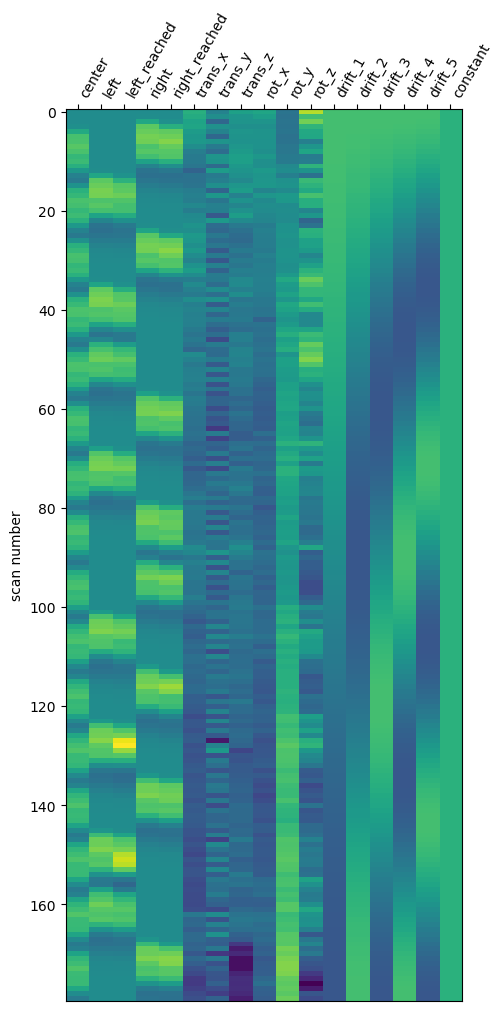

In [40]:
# ==============================================================================
# THE UNIFIED MASTER DRIVER: Optimized for Motif & Joystick
# ==============================================================================
SUB = "03"             
EXCLUDE_RUNS = ["02"]   

for run_data in data_runs:
    run_id = run_data['run']
    print(f"Processing Subject {SUB} - Run {run_id} ({run_data['dir']})")

# 1. FETCH AND FILTER RUNS
data_runs = get_motif_files(SUB) 
data_runs = [r for r in data_runs if r['run'] not in EXCLUDE_RUNS]
search_pattern = f"*{TASK}*sub-*{int(SUB)}*run-{int(run_id)}*events*"
ev_matches = list(EVENTS_DIR.glob(search_pattern))
ev_file = ev_matches[0]
ev_file
data = get_joystick_events(ev_file)
print(data['trial_type'].unique())
dm = build_the_design_matrix(nib.load(str(run_data['bold'])), ev, run_data['conf'])
dm.head()
plot_design_matrix(dm)

In [ ]:

# ==============================================================================
# 0. CONFIGURATION & THRESHOLDS (Optimized for 7T Exploration)
# ==============================================================================
SUB = "03"             
EXCLUDE_RUNS = ["02"]   
DISPLAY_THRESHOLD = 1.96  # Visualize everything above p < 0.01 (Z=2.3)

data_runs = get_motif_files(SUB) 
data_runs = [r for r in data_runs if r['run'] not in EXCLUDE_RUNS]

print(f"🚀 Starting {TASK.upper()} Pipeline for Subject {SUB}...")

for c_name, c_expr in CONTRASTS.items():
    print(f"\n" + "="*60)
    print(f"PROCESSING CONTRAST: {c_name}")
    print("="*60)

    SUB_METHOD_DIR = RESULTS_DIR / f"sub-{SUB}" / f"{METHOD}_method" / c_name
    SUB_METHOD_DIR.mkdir(parents=True, exist_ok=True)
    
    views_to_generate = CONTRAST_VIEWS.get(c_name, ["overview"])
    run_stats_list = []
    
    # --- STEP A: PROCESS INDIVIDUAL RUNS ---
    for run_data in data_runs:
        run_id = run_data['run']
        run_dir = SUB_METHOD_DIR / f"run-{run_id}_dir-{run_data['dir']}"
        run_dir.mkdir(exist_ok=True)
        
        # Load Events
        search_pattern = f"*{TASK}*sub-*{int(SUB)}*run-{int(run_id)}*events*"
        ev_matches = list(EVENTS_DIR.glob(search_pattern))
        ev = get_joystick_events(ev_matches[0]) 
        
        # GLM Fitting
        dm = build_the_design_matrix(nib.load(str(run_data['bold'])), ev, run_data['conf'])
        stats = fit_run_and_save_nifti(run_data['bold'], run_data['mask'], dm, run_dir, c_name, c_expr, SMOOTHING_FWHM)
        run_stats_list.append(stats)
        
        # Individual Run QC Plots
        for v_name in views_to_generate:
            save_brain_viz(
                stats['z_score'], 
                run_dir / f"{c_name}_run-{run_id}_{v_name}_viz.png", 
                title=f"Run {run_id} ({v_name}): {c_name}",
                sub_id=SUB, coords=ROI_COORDS.get(v_name, (0,0,0)) ,
                threshold=DISPLAY_THRESHOLD
            )



    # --- STEP B: SUBJECT FUSION (FIXED EFFECTS) ---
    print(f"  > [Subject Fusion] Combining {len(run_stats_list)} runs...")
    total_dir = SUB_METHOD_DIR / "combined_total"
    results = subject_fusion_and_save_data(
        run_stats_list, data_runs[0]['mask'], total_dir, c_name,
        alpha_fdr=ALPHA_FDR, alpha_bonf=ALPHA_BONF, cluster_thresh=CLUSTER_THRESHOLD
    )

    # --- STEP C: AUTO-PEAK DISCOVERY ---
    # We find the peak in the FDR map (the 'smartest' map)
    dynamic_peak = get_best_coords(results['z_fdr'],run_data['mask'] )
    
    if dynamic_peak:
        print(f"  ⭐ PEAK DISCOVERED AT: {np.round(dynamic_peak, 1)}")
    
    # --- STEP D: FINAL SCIENTIFIC PLOTS ---
    # Combine static ROIs with the discovered Dynamic Peak
    final_views = views_to_generate.copy()
    if dynamic_peak:
        final_views.append("AUTO_PEAK")

    for v_name in final_views:
        if v_name == "AUTO_PEAK":
            coords = dynamic_peak
            v_label = f"PEAK_{np.round(coords,0)}"
        else:
            coords = ROI_COORDS.get(v_name, (0,0,0))
            v_label = v_name
        print(final_views)

        # Save FDR Map
        save_brain_viz(
            results['z_fdr'], 
            total_dir / f"TOTAL_05_zmap_FDR_{v_name}.png", 
            f"Z (FDR {v_name}, Z > {results['fdr_threshold']:.2f}): {c_name}", 
            sub_id=SUB, coords=coords, threshold=1e-6
        )

        # Save Bonferroni Map
        save_brain_viz(
            results['z_bonf'], 
            total_dir / f"TOTAL_05_zmap_BONF_{v_name}.png", 
            f"Z (Bonf {v_name}, Z > {results['bonf_threshold']:.2f}): {c_name}", 
            sub_id=SUB, coords=coords, threshold=1e-6
        )

print(f"\n✅ PIPELINE COMPLETE: Subject {SUB} processed for {len(CONTRASTS)} contrasts.")

🚀 Starting JOYSTICK Pipeline for Subject 03...

PROCESSING CONTRAST: task_gt_baseline
[make_first_level_design_matrix] A 'modulation' column was found in the given events data and is used.


/tmp/ipykernel_1511347/3460312737.py:19: UserWarning: If design matrices are supplied, [t_r] will be ignored.
  ).fit(bold_img, design_matrices=dm)


[make_first_level_design_matrix] A 'modulation' column was found in the given events data and is used.


/tmp/ipykernel_1511347/3460312737.py:19: UserWarning: If design matrices are supplied, [t_r] will be ignored.
  ).fit(bold_img, design_matrices=dm)


  > [Subject Fusion] Combining 2 runs...
['M1_hand_L', 'SMA', 'overview']
['M1_hand_L', 'SMA', 'overview']
['M1_hand_L', 'SMA', 'overview']

PROCESSING CONTRAST: right_vs_left
[make_first_level_design_matrix] A 'modulation' column was found in the given events data and is used.


...

  > [Subject Fusion] Combining 2 runs...
['IPS_L', 'IPS_R', 'overview']
['IPS_L', 'IPS_R', 'overview']
['IPS_L', 'IPS_R', 'overview']

PROCESSING CONTRAST: target_achieved
[make_first_level_design_matrix] A 'modulation' column was found in the given events data and is used.


/tmp/ipykernel_1511347/3460312737.py:19: UserWarning: If design matrices are supplied, [t_r] will be ignored.
  ).fit(bold_img, design_matrices=dm)


[make_first_level_design_matrix] A 'modulation' column was found in the given events data and is used.


/tmp/ipykernel_1511347/3460312737.py:19: UserWarning: If design matrices are supplied, [t_r] will be ignored.
  ).fit(bold_img, design_matrices=dm)


KeyboardInterrupt: 

In [ ]:
# ==============================================================================
# THE UNIFIED MASTER DRIVER: Optimized for Motif & Joystick
# ==============================================================================
SUB = "03"             
EXCLUDE_RUNS = ["02"]   
DISPLAY_THRESHOLD = 2.3  # Visualize everything above p < 0.01 (Z=2.3)

# 1. FETCH AND FILTER RUNS
data_runs = get_motif_files(SUB) 
data_runs = [r for r in data_runs if r['run'] not in EXCLUDE_RUNS]

print(f"🚀 Starting {TASK.upper()} Pipeline for Subject {SUB}...")

for c_name, c_expr in CONTRASTS.items():
    print(f"\n" + "="*60)
    print(f"PROCESSING CONTRAST: {c_name}")
    print("="*60)

    # 1. PATH SETUP (Uses your existing perfect results structure)
    SUB_METHOD_DIR = RESULTS_DIR / f"sub-{SUB}" / f"{METHOD}_method" / c_name
    SUB_METHOD_DIR.mkdir(parents=True, exist_ok=True)
    
    views_to_generate = CONTRAST_VIEWS.get(c_name, ["overview"])
    run_stats_list = []
    
    # --- STEP A: PROCESS INDIVIDUAL RUNS ---
    for run_data in data_runs:
        run_id = run_data['run']
        run_dir = SUB_METHOD_DIR / f"run-{run_id}_dir-{run_data['dir']}"
        run_dir.mkdir(exist_ok=True)
        
        # --- A.1: DYNAMIC EVENT LOADING ---
        search_pattern = f"*{TASK}*sub-*{int(SUB)}*run-{int(run_id)}*events*"
        ev_matches = list(EVENTS_DIR.glob(search_pattern))
        ev = get_joystick_events(ev_matches[0])
        ev['duration'] = 1.0
        dm = build_the_design_matrix(nib.load(str(run_data['bold'])), ev, run_data['conf'])
        
        print(f"  > [Run {run_id}] Fitting GLM...")
        stats = fit_run_and_save_nifti(run_data['bold'], run_data['mask'], dm, run_dir, c_name, c_expr, SMOOTHING_FWHM)
        run_stats_list.append(stats)
        
        # SAVE QC PLOTS PER VIEW
        for v_name in views_to_generate:
            coords = ROI_COORDS[v_name]
            save_brain_viz(
                stats['z_score'], 
                run_dir / f"{c_name}_run-{run_id}_{v_name}_viz.png", 
                title=f"Run {run_id} ({v_name}): {c_name}",
                sub_id=SUB, coords=coords, threshold=3.1 
            )
            save_brain_viz(
                stats['z_score'], 
                run_dir / f"{c_name}_run-{run_id}_{v_name}_viz.png", 
                title=f"Run {run_id} ({v_name}): {c_name}",
                sub_id=SUB, coords=coords, threshold=3.1 
            )


    print(f"  > [Subject Fusion] Combining {len(run_stats_list)} runs...")
    total_dir = SUB_METHOD_DIR / "combined_total"
    results = subject_fusion_and_save_data(
        run_stats_list, data_runs[0]['mask'], total_dir, c_name,
        alpha_fdr=ALPHA_FDR, alpha_bonf=ALPHA_BONF, cluster_thresh=CLUSTER_THRESHOLD
    )

    # --- STEP C: THE SCIENTIFIC MAPS (Your perfect view parameters) ---
    for v_name in views_to_generate:
        coords = ROI_COORDS[v_name]
        # 1. Z-MAP FDR
        save_brain_viz(
            results['z_fdr'], 
            total_dir / f"TOTAL_05_zmap_FDR_{v_name}.png", 
            f"Z (FDR {v_name}, Z > {results['fdr_threshold']:.2f}): {c_name}", 
            sub_id=SUB, coords=coords, threshold=DISPLAY_THRESHOLD
        )

        # 2. Z-MAP BONFERRONI
        save_brain_viz(
            results['z_bonf'], 
            total_dir / f"TOTAL_06_zmap_BONF_{v_name}.png", 
            f"Z (Bonf {v_name}, Z > {results['bonf_threshold']:.2f}): {c_name}", 
            sub_id=SUB, coords=coords, threshold=DISPLAY_THRESHOLD
        )

    print(f"✅ PIPELINE COMPLETE: Sub-{SUB} / {TASK} / {METHOD}")

🚀 Starting JOYSTICK Pipeline for Subject 03...

PROCESSING CONTRAST: task_gt_baseline
[make_first_level_design_matrix] A 'modulation' column was found in the given events data and is used.
  > [Run 01] Fitting GLM...


/tmp/ipykernel_1509012/3460312737.py:19: UserWarning: If design matrices are supplied, [t_r] will be ignored.
  ).fit(bold_img, design_matrices=dm)


[make_first_level_design_matrix] A 'modulation' column was found in the given events data and is used.
  > [Run 03] Fitting GLM...


/tmp/ipykernel_1509012/3460312737.py:19: UserWarning: If design matrices are supplied, [t_r] will be ignored.
  ).fit(bold_img, design_matrices=dm)


  > [Subject Fusion] Combining 2 runs...
✅ PIPELINE COMPLETE: Sub-03 / joystick / sequence

PROCESSING CONTRAST: right_vs_left
[make_first_level_design_matrix] A 'modulation' column was found in the given events data and is used.
  > [Run 01] Fitting GLM...


...

  > [Subject Fusion] Combining 2 runs...
✅ PIPELINE COMPLETE: Sub-03 / joystick / sequence

PROCESSING CONTRAST: return_gt_move
[make_first_level_design_matrix] A 'modulation' column was found in the given events data and is used.
  > [Run 01] Fitting GLM...


/tmp/ipykernel_1509012/3460312737.py:19: UserWarning: If design matrices are supplied, [t_r] will be ignored.
  ).fit(bold_img, design_matrices=dm)


[make_first_level_design_matrix] A 'modulation' column was found in the given events data and is used.
  > [Run 03] Fitting GLM...


/tmp/ipykernel_1509012/3460312737.py:19: UserWarning: If design matrices are supplied, [t_r] will be ignored.
  ).fit(bold_img, design_matrices=dm)


  > [Subject Fusion] Combining 2 runs...
✅ PIPELINE COMPLETE: Sub-03 / joystick / sequence


In [ ]:
# ==============================================================================
# THE MASTER DRIVER: Multi-View & QC (M1 + SMA)
# ==============================================================================
SUB = "05"  # Change this to "01", "05", etc.

data_runs = get_motif_files(SUB) 

print(f"🚀 Starting Industrial Pipeline for Subject {SUB}...")
print(f"📂 Method: {METHOD.upper()}")

for c_name, c_expr in CONTRASTS.items():
    print(f"\n" + "="*60)
    print(f"PROCESSING CONTRAST: {c_name}")
    print("="*60)

    # 1. PATH SETUP
    SUB_METHOD_DIR = RESULTS_DIR / f"sub-{SUB}" / f"{METHOD}_method" / c_name
    print(f"📁 Setting up directory: {SUB_METHOD_DIR}")
    SUB_METHOD_DIR.mkdir(parents=True, exist_ok=True)
    
    # 2. GET VIEWS (e.g., ["M1_hand_R", "SMA"])
    views_to_generate = CONTRAST_VIEWS.get(c_name, ["overview"])
    run_stats_list = []
    
    # --- STEP A: PROCESS INDIVIDUAL RUNS ---
    for run_data in data_runs:
        run_id = run_data['run']
        run_dir = SUB_METHOD_DIR / f"run-{run_id}_dir-{run_data['dir']}"
        run_dir.mkdir(exist_ok=True)
        
        # Decide which events to use (Sequence vs Behavioral)
        if METHOD == "sequence":
            ev = build_events_sequence(int(run_id))
        elif METHOD == "behavioral":
            log_files = list(LOGS_DIR.glob(f"*sub-{int(SUB)}_run-{int(run_id)}*.csv"))
            ev = build_behavioral_file(log_files[0])

        # Build Design Matrix & Fit GLM
        dm = build_the_design_matrix(nib.load(str(run_data['bold'])), ev, run_data['conf'])
        
        print(f"  > [Run {run_id}] Fitting GLM...")
        stats = fit_run_and_save_nifti(run_data['bold'], run_data['mask'], dm, run_dir, c_name, c_expr, SMOOTHING_FWHM)
        run_stats_list.append(stats)
        
        # SAVE QC PLOTS PER VIEW (M1, SMA, etc.)
        for v_name in views_to_generate:
            coords = ROI_COORDS[v_name]
            save_brain_viz(
                stats['z_score'], 
                run_dir / f"{c_name}_run-{run_id}_{v_name}_viz.png", 
                title=f"Run {run_id} ({v_name}): {c_name}",
                sub_id=SUB,  
                coords=coords, 
                threshold=3.1 # <-- QC threshold for individual runs
            )

    # --- STEP B: FUSE ALL RUNS ---
    if not run_stats_list: 
        continue

    print(f"  > [Subject Fusion] Combining {len(run_stats_list)} runs...")
    total_dir = SUB_METHOD_DIR / "combined_total"
    
    results = subject_fusion_and_save_data(
        run_stats_list, data_runs[0]['mask'], total_dir, c_name,
        alpha_fdr=ALPHA_FDR, alpha_bonf=ALPHA_BONF, cluster_thresh=CLUSTER_THRESHOLD
    )

    # --- STEP C: THE SCIENTIFIC MAPS (PER VIEW) ---
    print(f"  > Generating Final Maps for views: {views_to_generate}")

    for v_name in views_to_generate:
        coords = ROI_COORDS[v_name]

        # 1. Z-MAP FDR
        save_brain_viz(
            results['z_fdr'], 
            total_dir / f"TOTAL_05_zmap_FDR_{v_name}.png", 
            f"Z (FDR {v_name}, Z > {results['fdr_threshold']:.2f}): {c_name}", 
            sub_id=SUB, coords=coords
        )

        # 2. Z-MAP BONFERRONI
        save_brain_viz(
            results['z_bonf'], 
            total_dir / f"TOTAL_06_zmap_BONF_{v_name}.png", 
            f"Z (Bonf {v_name}, Z > {results['bonf_threshold']:.2f}): {c_name}", 
            sub_id=SUB, coords=coords
        )

    del results # Memory safety
    print(f"✅ PIPELINE COMPLETE: Sub-{SUB} / {METHOD}_method")